In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO, DQN
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecVideoRecorder
import os 
import do_mpc
from casadi import vertcat
from scipy.linalg import solve_discrete_are


This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      183
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      180

Total number of variables............................:      123
                     variables with only lower bounds:        0
                variables with lower and upper bounds:      117
                     variables with only upper bounds:        0
Total number of equality constraints.................:       63
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  8.4230228e+03 1.00e-02 6.40e+01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

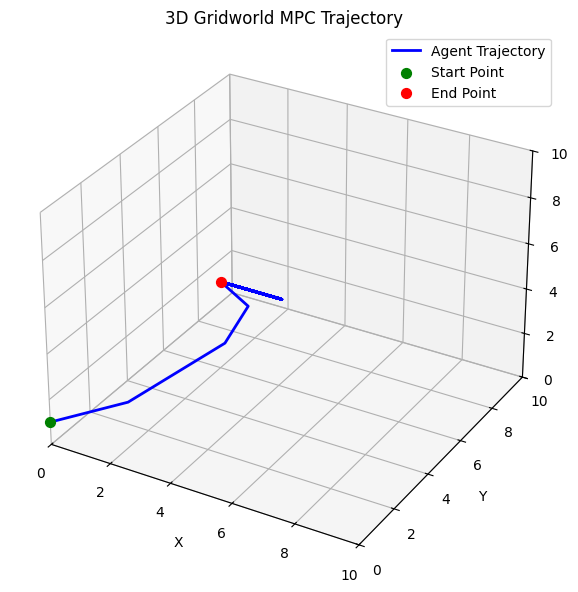

In [22]:
import numpy as np
import casadi as ca
import do_mpc
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def create_model():
    model_type = 'discrete'
    model = do_mpc.model.Model(model_type)

    # States: Integer states between 0 and 10 for each axis
    x = model.set_variable(var_type='_x', var_name='x', shape=(1, 1))
    y = model.set_variable(var_type='_x', var_name='y', shape=(1, 1))
    z = model.set_variable(var_type='_x', var_name='z', shape=(1, 1))

    # Inputs: Discrete control inputs (move in x, y, z direction)
    move_x = model.set_variable(var_type='_u', var_name='move_x', shape=(1, 1))
    move_y = model.set_variable(var_type='_u', var_name='move_y', shape=(1, 1))
    move_z = model.set_variable(var_type='_u', var_name='move_z', shape=(1, 1))

    dt = 1  # Discrete timestep (each step represents moving one grid unit)

    # Dynamics: State update is integer-based movement (move by -1, 0, or +1)
    model.set_rhs('x', x + move_x * dt)
    model.set_rhs('y', y + move_y * dt)
    model.set_rhs('z', z + move_z * dt)

    model.setup()
    return model

def create_mpc(model):
    mpc = do_mpc.controller.MPC(model)
    setup_mpc = {
        'n_horizon': 20,
        't_step': 1,  # each timestep is 1 step in grid
        'store_full_solution': True
    }
    mpc.set_param(**setup_mpc)

    # Weights
    w_xy = 1.0
    w_z = 2.0
    w_ceil = 50.0
    w_u = 0.1
    w_center = 5.0  # Penalize distance from the center

    # Cost function:
    # 1. Encourage movement towards the target z=7
    # 2. Penalize being near the boundaries
    # 3. Encourage being near the center (x=5, y=5, z=5)
    mterm = w_xy*(model.x['x']**2 + model.x['y']**2) + \
            w_z*(model.x['z'] - 7)**2 + \
            w_ceil*ca.fmax(0, model.x['z'] - 9)**2 + \
            w_center*((model.x['x'] - 5)**2 + (model.x['y'] - 5)**2 + (model.x['z'] - 5)**2)

    lterm = mterm

    mpc.set_objective(mterm=mterm, lterm=lterm)

    # Control effort penalty (use this for move_x, move_y, and move_z)
    mpc.set_rterm(move_x=w_u, move_y=w_u, move_z=w_u)

    # Bounds for each direction (control inputs: -1, 0, or 1)
    mpc.bounds['lower','_u','move_x'] = -1
    mpc.bounds['upper','_u','move_x'] = 1
    mpc.bounds['lower','_u','move_y'] = -1
    mpc.bounds['upper','_u','move_y'] = 1
    mpc.bounds['lower','_u','move_z'] = -1
    mpc.bounds['upper','_u','move_z'] = 1

    # Bounds for the state variables (x, y, z)
    mpc.bounds['lower','_x','x'] = 0
    mpc.bounds['upper','_x','x'] = 10
    mpc.bounds['lower','_x','y'] = 0
    mpc.bounds['upper','_x','y'] = 10
    mpc.bounds['lower','_x','z'] = 0
    mpc.bounds['upper','_x','z'] = 10

    mpc.setup()
    return mpc


def simulate():
    model = create_model()
    mpc = create_mpc(model)
    simulator = do_mpc.simulator.Simulator(model)
    simulator.set_param(t_step=1)  # each timestep is 1 step in grid
    simulator.setup()

    # Initial state: start near the origin but under the target Z
    x0 = np.array([0, 0, 1])  # Initial positions in integer grid (0-10)
    mpc.x0 = x0
    simulator.x0 = x0
    mpc.set_initial_guess()

    # Logging states
    traj = [x0.copy()]

    for _ in range(50):  # simulate 50 steps (5 grid steps)
        u0 = mpc.make_step(x0)
        x0 = simulator.make_step(u0)
        # add random noise to the x state by flipping a coin and adding 1 to x dimension
        if np.random.rand() < 0.5:
            x0[0] += 1
        traj.append(np.array(x0).flatten())

    return np.array(traj)

def plot_trajectory(traj):
    x, y, z = traj[:, 0], traj[:, 1], traj[:, 2]

    # Plot the trajectory
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(x, y, z, label='Agent Trajectory', color='blue', lw=2)

    # Plot starting and ending points
    ax.scatter(x[0], y[0], z[0], color='green', s=50, label='Start Point')
    ax.scatter(x[-1], y[-1], z[-1], color='red', s=50, label='End Point')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title('3D Gridworld MPC Trajectory')
    ax.set_xlim([0, 10])
    ax.set_ylim([0, 10])
    ax.set_zlim([0, 10])

    # Add legend
    ax.legend()

    plt.tight_layout()
    plt.show()

# Run the simulation and plot the results
traj = simulate()
plot_trajectory(traj)
